#### Import libraries and load Dataset

In [169]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [170]:
housing_df = pd.read_csv('./housing.csv')
housing_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


**Cleaning and Exploring**

In [171]:
housing_df.shape

(20640, 10)

**Observation:**
- 20 640 rows / data
- 10 columns / features




In [172]:
housing_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [173]:
housing_df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


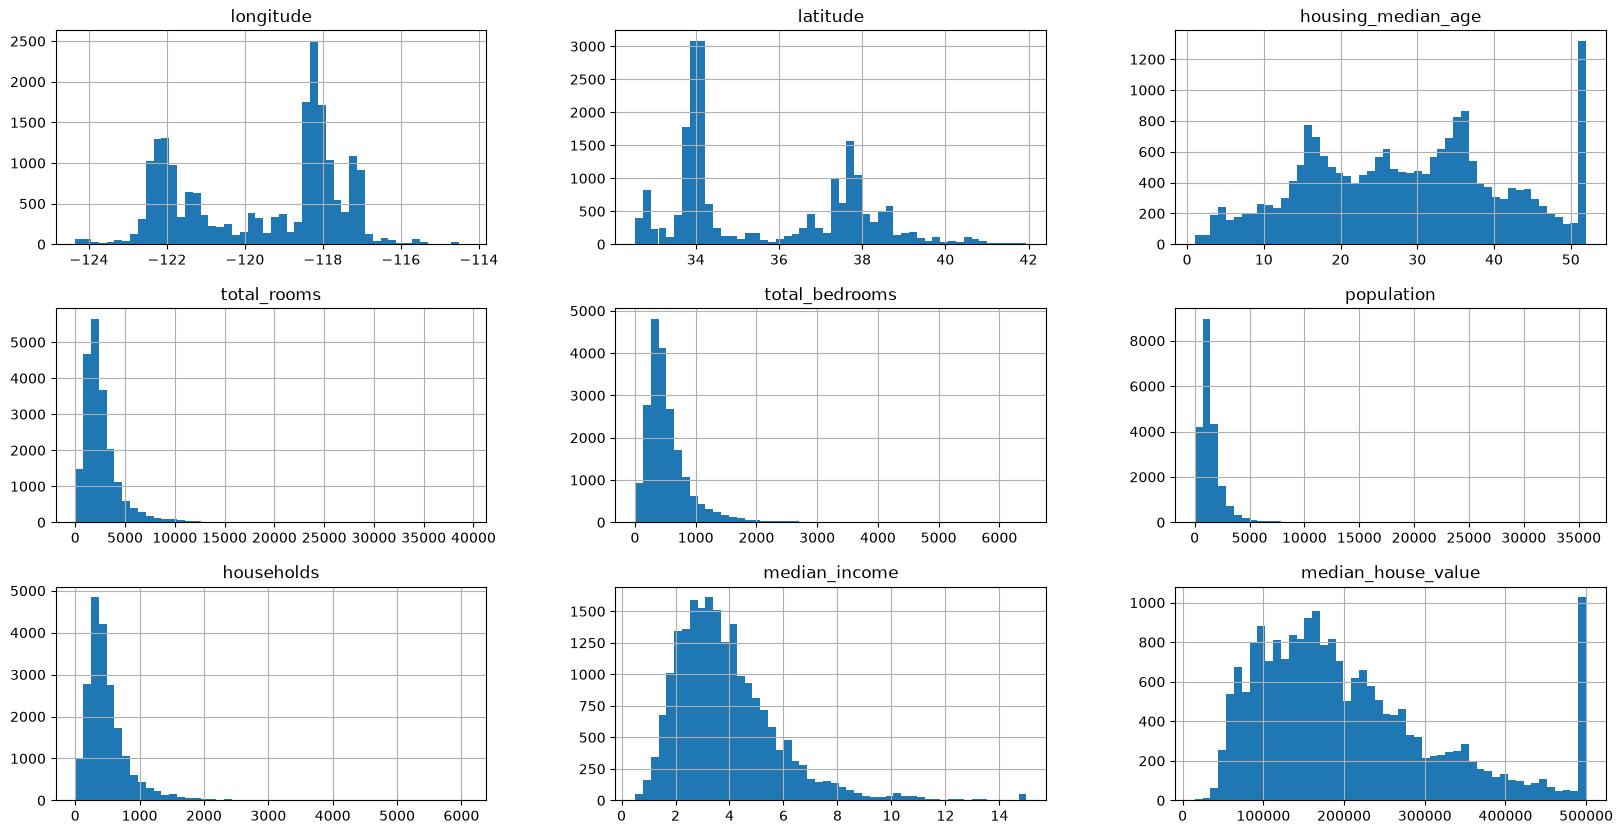

In [174]:
housing_df.hist(bins=50,figsize=(20,10))
plt.show()

Null rows

In [175]:
housing_df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [176]:
housing_df = housing_df.dropna()

In [177]:
housing_df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [178]:
housing_df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9034
INLAND        6496
NEAR OCEAN    2628
NEAR BAY      2270
ISLAND           5
Name: count, dtype: int64

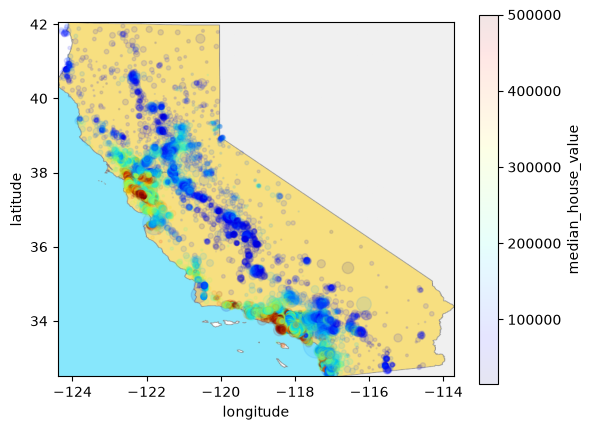

In [179]:
calif = plt.imread('./image/images.png')

housing_df.plot(kind='scatter',x ='longitude',y='latitude',alpha = 0.1,
               s=housing_df['population']/100,
                c='median_house_value',cmap =plt.get_cmap('jet') )

plt.imshow(calif, extent=[-124.4,-113.7,32.5,42.05],alpha=0.5,cmap=plt.get_cmap('jet'))

Correlation

In [180]:
housing_df_copied = housing_df.copy()

**Feature Engineering**

In [181]:
housing_df_copied['bedrooms_per_room'] = housing_df_copied['total_bedrooms'] / housing_df_copied['total_rooms']
housing_df_copied['population_per_household'] = housing_df_copied['population']/ housing_df_copied['households']
housing_df_copied['rooms_per_household'] = housing_df_copied['total_rooms']/housing_df_copied['households']

In [182]:
corr_matrix = housing_df_copied.drop(columns='ocean_proximity').corr()
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.688355
rooms_per_household         0.151344
total_rooms                 0.133294
housing_median_age          0.106432
households                  0.064894
total_bedrooms              0.049686
population_per_household   -0.023639
population                 -0.025300
longitude                  -0.045398
latitude                   -0.144638
bedrooms_per_room          -0.255880
Name: median_house_value, dtype: float64

fig,ax = plt.subplots(2,2)
for i, col in enumerate(column):
    if i < 3:
        ax[0,i].plot(x=housing_df_final[col],)
    else:
        ax[]

<Axes: >

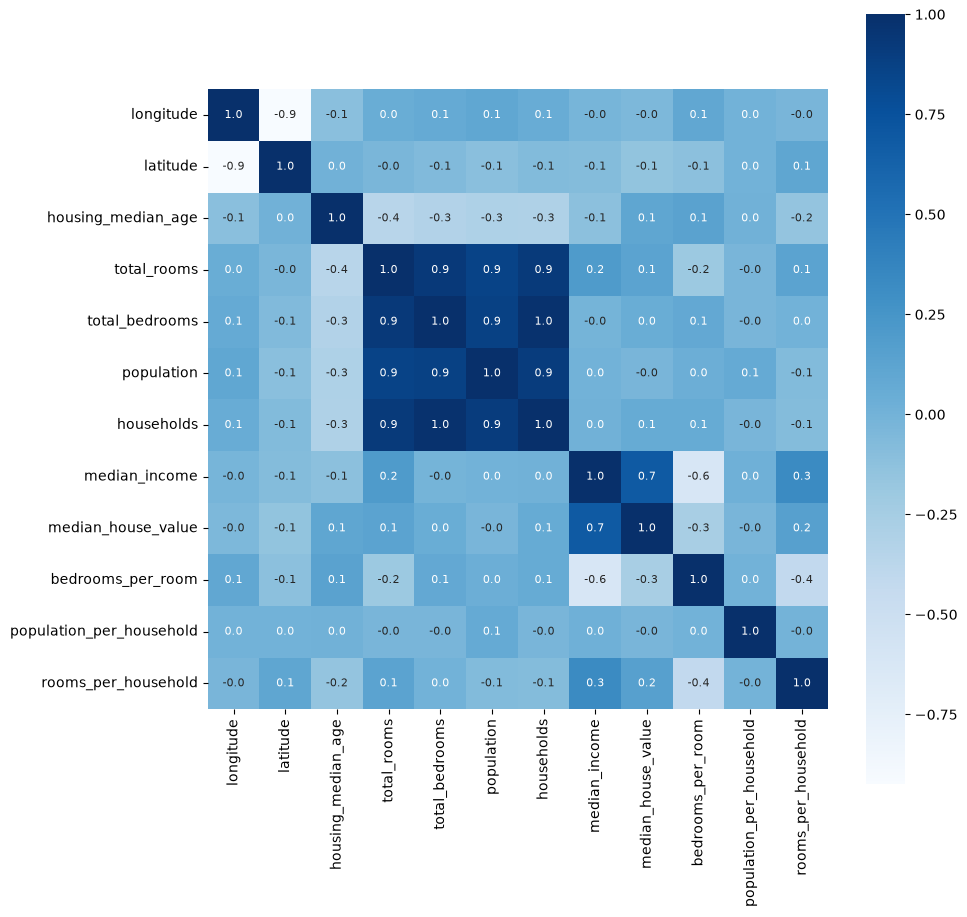

In [183]:
import seaborn as sns



plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix,cbar=True,square=True,fmt='.1f',
            annot=True,annot_kws={'size':8},cmap='Blues')

**Observation:** The new created feature `bedrooms_per_room` shows the high correralation:
- Houses with less bedroom will tend to be more expensive

**Preprocessing**

**Split the dataset into Train, Test, and Validation**

In [184]:
housing_df_copied = housing_df_copied[
    ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity', 'bedrooms_per_room',
       'population_per_household', 'rooms_per_household',
       'median_house_value'
       ]
]

In [185]:
X = housing_df_copied.iloc[:,:-1]
y = housing_df_copied.iloc[:,-1]


In [186]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [187]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.metrics import root_mean_squared_error

In [188]:
num_cols = housing_df_copied.select_dtypes(include='number').columns.tolist()
cat_cols = housing_df_copied.select_dtypes(include=['object','string']).columns.tolist()

num_cols =['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'bedrooms_per_room',
 'population_per_household',
 'rooms_per_household']


In [189]:
X

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,bedrooms_per_room,population_per_household,rooms_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,NEAR BAY,0.146591,2.555556,6.984127
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,NEAR BAY,0.155797,2.109842,6.238137
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,NEAR BAY,0.129516,2.802260,8.288136
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,NEAR BAY,0.184458,2.547945,5.817352
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,NEAR BAY,0.172096,2.181467,6.281853
...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,INLAND,0.224625,2.560606,5.045455
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,INLAND,0.215208,3.122807,6.114035
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,INLAND,0.215173,2.325635,5.205543
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,INLAND,0.219892,2.123209,5.329513


In [190]:
cat_cols

['ocean_proximity']

Pipeline

In [191]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),num_cols),
        ('cat',OneHotEncoder(handle_unknown='ignore'),cat_cols)
    ]
)

Linear Regression

In [192]:
from sklearn.linear_model import LinearRegression


lr = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',LinearRegression())
])


In [193]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    lr,X_train,
    y_train,cv=kf,
    scoring='neg_root_mean_squared_error'
)

print(scores)
print(-scores.mean())

lr.fit(X_train, y_train)
y_pred_train = lr.predict(X_train)
y_pred_test = lr.predict(X_test)


print('RMSE for Train: ', root_mean_squared_error(y_true=y_train,y_pred=y_pred_train))
print('RMSE for Test: ', root_mean_squared_error(y_true=y_test,y_pred=y_pred_test))



[-65492.31803479 -67499.46969757 -67977.01912378 -69572.15656559
 -69412.0176637 ]
67990.59621708616
RMSE for Train:  67636.9119274096
RMSE for Test:  69042.79968866508


KNN

In [194]:
from sklearn.neighbors import KNeighborsRegressor

knn  = Pipeline( steps=[
    ('preprocessor',preprocessor),
    ('model', KNeighborsRegressor(n_neighbors=15))
]

)

In [195]:
scores = cross_val_score(knn,X=X_train,y=y_train,
                         cv=kf,scoring='neg_root_mean_squared_error')

print(scores)
print(-scores.mean())

knn.fit(X_train,y_train)

y_pred_train = knn.predict(X_train)
y_pred_test = knn.predict(X_test)


print('RMSE for Train: ', root_mean_squared_error(y_true=y_train,y_pred=y_pred_train))
print('RMSE for Test: ', root_mean_squared_error(y_true=y_test,y_pred=y_pred_test))



[-59795.7515456  -61289.08770199 -62574.15138267 -62742.10242083
 -59816.78895742]
61243.57640170192
RMSE for Train:  56569.00824040195
RMSE for Test:  60632.183916432725


Random Forest

In [196]:
from sklearn.ensemble import RandomForestRegressor
rfr = Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('model',RandomForestRegressor(max_depth=10))
    ]
)

In [197]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    rfr,X_train,
    y_train,cv=kf,
    scoring='neg_root_mean_squared_error'
)

print(scores)
print(-scores.mean())

rfr.fit(X_train, y_train)
y_pred_train = rfr.predict(X_train)
y_pred_test = rfr.predict(X_test)


print('RMSE for Train: ', root_mean_squared_error(y_true=y_train,y_pred=y_pred_train))
print('RMSE for Test: ', root_mean_squared_error(y_true=y_test,y_pred=y_pred_test))



[-51597.43347625 -52481.27406274 -53626.72486702 -53935.3229336
 -51581.46924605]
52644.444917132074
RMSE for Train:  41580.002893986086
RMSE for Test:  53984.840907368605


Gradient Boosting

In [198]:
from sklearn.ensemble import GradientBoostingRegressor

gb = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',GradientBoostingRegressor(n_estimators=250))
])

In [199]:
scores = cross_val_score(
    gb,X_train,y_train,cv=kf,scoring='neg_root_mean_squared_error')

print(scores)
print(-scores.mean())

gb.fit(X_train,y_train)

y_pred_train = gb.predict(X_train)
y_pred_test = gb.predict(X_test)


print('RMSE for Train: ', root_mean_squared_error(y_true=y_train,y_pred=y_pred_train))
print('RMSE for Test: ', root_mean_squared_error(y_true=y_test,y_pred=y_pred_test))

[-48121.6372657  -49099.55999845 -50228.66964833 -50437.33357591
 -49158.77633722]
49409.19536512264
RMSE for Train:  44989.28845066569
RMSE for Test:  50537.185737478285


XGBRegressor

In [200]:
from xgboost import XGBRegressor

xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model',XGBRegressor())
])

In [201]:
scores = cross_val_score(xgb, X_train,
                         y_train,cv=kf,scoring='neg_root_mean_squared_error')

print(scores)
print(-scores.mean())

xgb.fit(X_train,y_train)


y_pred_train = xgb.predict(X_train)
y_pred_test = xgb.predict(X_test)


print('RMSE for Train: ', root_mean_squared_error(y_true=y_train,y_pred=y_pred_train))
print('RMSE for Test: ', root_mean_squared_error(y_true=y_test,y_pred=y_pred_test))

[-45996.84506888 -46008.666884   -48636.73901868 -47281.75983841
 -46704.23445153]
46925.64905230096
RMSE for Train:  26460.867637860203
RMSE for Test:  47197.47828880938


In [174]:
mse = mean_squared_error(xgb.predict(X_train),y_train,squared=False)
print('Root Mean Squared error: ',mse)
rmse = mean_squared_error(xgb.predict(X_val),y_val,squared=False)
print('Root mean squared error:',rmse)


Root Mean Squared error:  29342.558943158565
Root mean squared error: 48493.5811636237


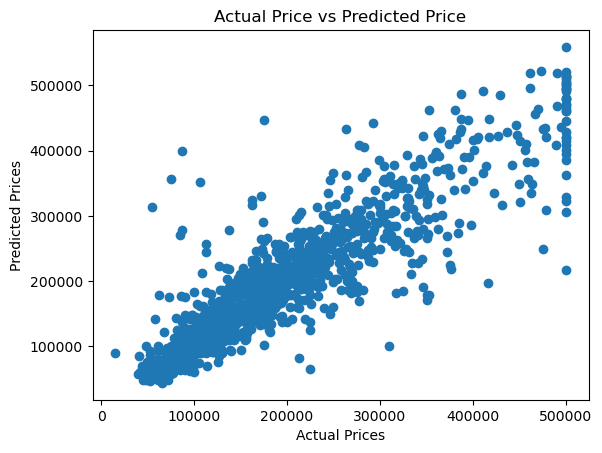

In [176]:
plt.scatter(y_val,xgb.predict(X_val))
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Price vs Predicted Price")
plt.show()

**Hyperparameter Tuning**

In [62]:
from sklearn.model_selection import GridSearchCV


Random Forest

In [63]:
param_grid = {
    'n_estimators' :[100,200,250],
    'max_depth':[None,10,20],
    'min_samples_split': [2,5],
    'min_samples_leaf': [1,2]
}

grid_search = GridSearchCV(RandomForestRegressor(),param_grid=param_grid,cv=5)
grid_search.fit(X_train,y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Estimator:", grid_search.best_estimator_)


KeyboardInterrupt: 

Gradient Boosting

XGBRegressor

In [ ]:
param_grid = {
    'n_estimors': [10,100,200],
    'learning_rate': [0.01,0.1,0.2],
    'max_depth': [3,5,7],
    'subsample': [0.8,1.0]
}

grid_search = GridSearchCV(GradientBoostingRegressor(),
                           param_grid=param_grid,
                           cv=5,
                           scoring='neg_root_mean_squared_error',
                           n_jobs=-1)
grid_search.fit(X_train,y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Estimator:", grid_search.best_estimator_)